<a href="https://colab.research.google.com/github/hsultova/Softuni-AI-Agents-Workflows/blob/main/exam/exam_multi_agent_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up


*   OPENAI_API_KEY must be set as a Colab secret
*   Data file (recipes.md) should be uploaded if not found at /content/



# TODO: Project description

In [1]:
!pip install -q langchain langchain-openai langchain_text_splitters langchain_chroma

In [2]:
import json
import operator

from typing import TypedDict, Literal, Annotated
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from IPython.display import Image

from google.colab import userdata, files

from langchain_openai import ChatOpenAI
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain.messages import HumanMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate
from langchain.tools import ToolRuntime, tool
from langchain.agents import create_agent, AgentState

from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore


In [3]:
openai_api_key = SecretStr(userdata.get("OPENAI_API_KEY"))

In [4]:
class Recipe(BaseModel):
  name: str
  country: str
  description: str
  ingredients: str
  preparation: str
  fact: str

In [5]:
RECIPES_PATH = '/content/recipes.md'

if not Path(RECIPES_PATH).exists():
  uploaded = files.upload()
  path_to_pdf = Path(next(iter(uploaded)))

with open(RECIPES_PATH) as file:
    text = file.read()
documents = [Document(page_content=text, metadata={"source": RECIPES_PATH})]

In [6]:
headers_to_split_on = [
  ("##", "name"),
  ("###", "section"),
]
for document in documents:
  splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
  chunks = splitter.split_text(document.page_content)

  recipes = {}

  for chunk in chunks:
    name = chunk.metadata.get("name", "").strip()
    section = chunk.metadata.get("section")
    content = chunk.page_content.strip()

    if name not in recipes:
      recipes[name] = {"name": name, "country": "", "ingredients": "", "preparation": "", "fact": ""}

    if section is None:
      # This is the intro chunk: first line is the country, rest is description
      lines = content.split("\n")
      recipes[name]["country"] = lines[0].strip("* ").strip()
    elif section == "INGREDIENTS":
      recipes[name]["ingredients"] = content
    elif section == "PREPARATION":
      recipes[name]["preparation"] = content
    elif section == "GOOD TO KNOW":
      recipes[name]["fact"] = content


In [7]:
documents_to_store = []

for recipe in recipes.values():
  page_content = (
    f"{recipe['name']}\n"
    f"{recipe['country']}\n\n"
    f"Ingredients:\n{recipe['ingredients']}\n\n"
    f"Preparation:\n{recipe['preparation']}\n\n"
    f"Fact:\n{recipe['fact']}"
  )

  document = Document(
    page_content=page_content,
    metadata={
      "name": recipe["name"],
      "country": recipe["country"],
      "ingredients": recipe["ingredients"],
      "preparation": recipe["preparation"],
      "fact": recipe["fact"],
    },
  )
  documents_to_store.append(document)

In [8]:
recipes_chromadb = Chroma(collection_name="recipes_db", persist_directory="/content/chroma")

In [9]:
recipes_chromadb.add_documents(documents_to_store)

['86a077b2-c969-460f-85f2-b6ea218039f5',
 'fd3472e1-710b-49a3-86e9-fc6c6077084e',
 'c15abe95-9fa8-4f48-8ea3-f48ac216ce53',
 '1f774261-bbdd-4e47-b17b-c295564e06fe',
 '6dc61aad-af79-4902-8044-d1950aff84df',
 '5effdbaa-9f66-43e2-8833-73a4995aee51',
 'fe86fa71-045f-41ea-a955-8f4912ccb028',
 '72e3c906-2419-4d77-bc9a-7249b87d1984',
 '84b202bd-9d08-474a-ae6a-fa25516eeae7',
 'fc6b081a-1560-4a55-9baf-472c4458f574',
 '4720112f-4b49-4c92-a5fa-25ffdeb04f10',
 '1f154b30-475e-4a06-b44a-19750faaf1a0',
 '9f04388a-e631-4179-b745-013856850ca9',
 'b6840781-734e-4cc7-adcc-8527f7cae2ec',
 'b5588df6-c77f-486c-97ad-948efac78a36',
 'ee3a7de7-3391-45d2-b050-a36c4eff1940',
 '531836b3-e394-4560-b467-d78b9edf300e',
 'd2020b45-0984-47c0-9287-8ece2bff4075',
 '66488c70-8aca-4156-9a43-bc9dcdf36f73',
 'f7720c68-c93b-49e0-b7e9-7c9db4775547',
 '46b0a15a-c134-421d-81ef-f27a6d28ec02',
 'fa610319-b2d6-4005-8942-cd473da1b4d8',
 '2ef677f6-059e-4cbe-986e-66339bec7eef',
 '62948569-3dc5-4fad-88f7-4694f11d7813',
 '8019aa4f-ee70-

In [10]:
class RecipePlannerContext(TypedDict):
  user_id: str

class RecipePlannerState(AgentState):
  thread_notes: Annotated[list[str], operator.add]

In [11]:
class DietaryPreferences(BaseModel):
  diet_type: Literal["vegetarian","vegan","pescatarian", "mediterranean", "keto", "gluten-free", "no sugar", "other"]
  allergies: list[str] = Field(default_factory=list)
  allergies_confirmed: bool = Field(
    default=False,
    description=(
      "True only if the user was explicitly asked about allergies "
      "(this session or a prior one) and confirmed an answer, "
      "including 'none'. False means 'unknown', not 'no allergies'."
    ),
  ),
  dislikes: list[str] = Field(default_factory=list)
  servings: int = 4
  days: int = 7
  calorie_target: int | None = None
  budget: float | None = None
  cuisine_preferences: list[str] = Field(default_factory=list)

class RecipePlannerState(TypedDict):
  user_request: str
  dietary_preferences: DietaryPreferences
  validation: str

In [12]:
preferences_parser_model = ChatOpenAI(model="gpt-5.4-mini", api_key=openai_api_key, reasoning_effort="low").with_structured_output(DietaryPreferences)
preferences_parser_prompt = """You are extracting structured dietary preferences from a user's message for a
weekly meal-planning system. Output only the fields defined in the schema.

Rules:
- diet_type: infer from explicit statements only. Don't assume "healthy eating"
  implies vegetarian, etc.
- allergies: extract explicitly stated allergies/intolerances only. Do NOT infer
  additional allergies from dietary preferences (e.g. "vegan" does not imply a
  dairy allergy — it's a preference, not a safety constraint).
- If the user does not mention allergies at all, set allergies_confirmed=False
  and leave allergies=[]. Do not assume "no allergies mentioned" means
  "no allergies." This will trigger a clarifying question — that's intended.
- servings: if unstated, default to 4 and note the assumption in your reasoning.
- calorie_target / budget: leave null if not mentioned — do not estimate one.
- Normalize allergy/dislike terms to common ingredient names (e.g. "I can't do
  nuts" → "tree nuts"; "shellfish gives me hives" → "shellfish").

If the user references prior preferences you're given below, reconcile any
conflicts by favoring what they said in this message.
"""

/usr/local/lib/python3.13/dist-packages/pydantic/json_schema.py:2463: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=False, default=False, description="True only if the user was explicitly asked about allergies (this session or a prior one) and confirmed an answer, including 'none'. False means 'unknown', not 'no allergies'."),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [13]:
#TODO: To not be tools if not needed. Decide later.
### @tool
# def remember_preference(key: str, value: str, runtime: ToolRuntime[RecipePlannerContext, RecipePlannerState]) -> str:
#   """
#   Store persistent user preferences from the chat(e.g., dietary preferences, allergies, dislikes...).
#   """
#   namespace = ("users", runtime.context["user_id"], "preferences")
#   runtime.store.put(namespace, key, {"value": value})
#   return "User preferences stored successfully."

### @tool
# def recall_preferences(runtime: ToolRuntime[RecipePlannerContext, RecipePlannerState]) -> str:
#     """
#     Read the full preference list for the user. Call at the start of every session.
#     """
#     namespace = ("users", runtime.context["user_id"], "preferences")
#     preferences = runtime.store.search(namespace, limit=100)

#     result = []
#     if preferences:
#       result.append(
#             "User preferences:\n" +
#             "\n".join(f"- {i.key}: {i.value['value']}" for i in sorted(preferences, key=lambda i: i.key))
#       )

#     if not result:
#       return "No prefernces stored. This is a new user."

#     return "\n\n".join(result)

In [14]:
def parse_dietary_preferences(state: RecipePlannerState):
  #TODO: clarifying turn for allergies and other info
  print("Parse dietary preferences")
  user_request = state.get("user_request")
  preferences_response = preferences_parser_model.invoke(
    input=[
      SystemMessage(preferences_parser_prompt),
      HumanMessage(user_request)
      ]
    )

  return {"dietary_preferences": preferences_response}

def plan_meal(state: RecipePlannerState):
  print("Meal Planner")

def validate_meal_plan(state: RecipePlannerState):
  print("Plan validator")
  return {"validation": "valid"}

def route_after_validation(state: RecipePlannerState):
  validation = state.get("validation")
  return "shopping_list_builder" if validation is not None and validation == "valid" else "meal_planner"

def build_shopping_list(state: RecipePlannerState):
  print("Shopping list builder")

In [15]:
checkpointer = InMemorySaver()
store = InMemoryStore()

In [16]:
recipe_graph_builder = StateGraph(RecipePlannerState)
recipe_graph_builder.add_node("dietary_preferences", parse_dietary_preferences)
recipe_graph_builder.add_node("meal_planner", plan_meal)
recipe_graph_builder.add_node("plan_validator", validate_meal_plan)
recipe_graph_builder.add_node("shopping_list_builder", build_shopping_list)

recipe_graph_builder.add_edge(START, "dietary_preferences")
recipe_graph_builder.add_edge("dietary_preferences", "meal_planner")
recipe_graph_builder.add_edge("meal_planner", "plan_validator")
recipe_graph_builder.add_conditional_edges("plan_validator", route_after_validation, ["meal_planner", "shopping_list_builder"])
recipe_graph_builder.add_edge("shopping_list_builder", END)
recipe_graph = recipe_graph_builder.compile(checkpointer, debug=True)

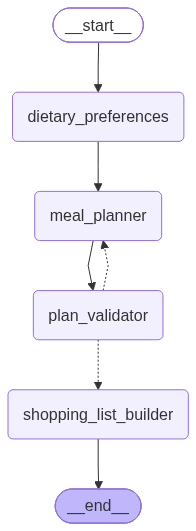

In [17]:
display(Image(data=recipe_graph.get_graph().draw_mermaid_png(), format="png"))

In [18]:
thread1_config = { "configurable": { "thread_id": "thread_2" } }

In [19]:
def execute_workflow(user_request: str):
  #initialize the graph

  # recipe_graph_builder = StateGraph(RecipePlannerState)
  # recipe_graph_builder.add_node("dietary_preferences", parse_dietary_preferences)
  # recipe_graph_builder.add_node("meal_planner", plan_meal)
  # recipe_graph_builder.add_node("plan_validator", validate_meal_plan)
  # recipe_graph_builder.add_node("shopping_list_builder", build_shopping_list)

  # recipe_graph_builder.add_edge(START, "dietary_preferences")
  # recipe_graph_builder.add_edge("dietary_preferences", "meal_planner")
  # recipe_graph_builder.add_edge("meal_planner", "plan_validator")
  # recipe_graph_builder.add_conditional_edges("plan_validator", validate_meal_plan, ["meal_planner", "shopping_list_builder"])
  # recipe_graph_builder.add_edge("shopping_list_builder", END)
  # recipe_graph = recipe_graph_builder.compile(debug=True)

  #begin execution
  recipe_graph.invoke(input={"user_request": user_request}, config=thread1_config)
  #interuption
  #resume
  #final output
  print("execute_workflow")

In [21]:
execute_workflow(user_request="Give me shopping list for vegetarian family of 4, $75/week budget")

/usr/local/lib/python3.13/dist-packages/pydantic/json_schema.py:2463: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=False, default=False, description="True only if the user was explicitly asked about allergies (this session or a prior one) and confirmed an answer, including 'none'. False means 'unknown', not 'no allergies'."),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


[values] {'user_request': 'Give me shopping list for vegetarian family of 4, $75/week budget', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=4, days=7, calorie_target=None, budget=75.0, cuisine_preferences=[]), 'validation': 'valid'}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=4, days=7, calorie_target=None, budget=75.0, cuisine_preferences=[])}}
[values] {'user_request': 'Give me shopping list for vegetarian family of 4, $75/week budget', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=4, days=7, calorie_target=None, budget=75.0, cuisine_preferences=[]), 'validation': 'valid'}
Meal Planner
[updates] {'meal_planner': None}
Plan validator
[updates] {'plan_validator': {'validation': 